In [1]:
print("hello")

hello


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set_palette("Set2")

In [4]:
df = pd.read_csv("data5.csv")

In [6]:
columns = [
    "Severity",
    "Start_Time",
    "Start_Lat",
    "Start_Lng",
    "City",
    "State",
    "Weather_Condition",
    "Temperature(F)",
    "Humidity(%)",
    "Visibility(mi)",
    "Wind_Speed(mph)",
    "Precipitation(in)",
    "Sunrise_Sunset",
    "Amenity",
    "Crossing",
    "Junction",
    "Traffic_Signal"
]

df = pd.read_csv("data5.csv", usecols=columns)

In [7]:
print("Shape:", df.shape)

df.head()

Shape: (7728394, 17)


,Severity,Start_Time,Start_Lat,Start_Lng,City,State,Temperature(F),Humidity(%),Visibility(mi),Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Crossing,Junction,Traffic_Signal,Sunrise_Sunset
0,3,2016-02-08 05:46:00,39.865147,-84.058723,Dayton,OH,36.9,91.0,10.0,NaN,0.02,Light Rain,False,False,False,False,Night
1,2,2016-02-08 06:07:59,39.928059,-82.831184,Reynoldsburg,OH,37.9,100.0,10.0,NaN,0.00,Light Rain,False,False,False,False,Night
2,2,2016-02-08 06:49:27,39.063148,-84.032608,Williamsburg,OH,36.0,100.0,10.0,3.5,NaN,Overcast,False,False,False,True,Night
3,3,2016-02-08 07:23:34,39.747753,-84.205582,Dayton,OH,35.1,96.0,9.0,4.6,NaN,Mostly Cloudy,False,False,False,False,Night
4,2,2016-02-08 07:39:07,39.627781,-84.188354,Dayton,OH,36.0,89.0,6.0,3.5,NaN,Mostly Cloudy,False,False,False,True,Day


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 17 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Severity           int64  
 1   Start_Time         str    
 2   Start_Lat          float64
 3   Start_Lng          float64
 4   City               str    
 5   State              str    
 6   Temperature(F)     float64
 7   Humidity(%)        float64
 8   Visibility(mi)     float64
 9   Wind_Speed(mph)    float64
 10  Precipitation(in)  float64
 11  Weather_Condition  str    
 12  Amenity            bool   
 13  Crossing           bool   
 14  Junction           bool   
 15  Traffic_Signal     bool   
 16  Sunrise_Sunset     str    
dtypes: bool(4), float64(7), int64(1), str(5)
memory usage: 796.0 MB


In [9]:
df.describe()

,Severity,Start_Lat,Start_Lng,Temperature(F),Humidity(%),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,7.728394e+06,7.728394e+06,7.728394e+06,7.564541e+06,7.554250e+06,7.551296e+06,7.157161e+06,5.524808e+06
mean,2.212384e+00,3.620119e+01,-9.470255e+01,6.166329e+01,6.483104e+01,9.090376e+00,7.685490e+00,8.407210e-03
std,4.875313e-01,5.076079e+00,1.739176e+01,1.901365e+01,2.282097e+01,2.688316e+00,5.424983e+00,1.102246e-01
min,1.000000e+00,2.455480e+01,-1.246238e+02,-8.900000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,3.339963e+01,-1.172194e+02,4.900000e+01,4.800000e+01,1.000000e+01,4.600000e+00,0.000000e+00
50%,2.000000e+00,3.582397e+01,-8.776662e+01,6.400000e+01,6.700000e+01,1.000000e+01,7.000000e+00,0.000000e+00
75%,2.000000e+00,4.008496e+01,-8.035368e+01,7.600000e+01,8.400000e+01,1.000000e+01,1.040000e+01,0.000000e+00
max,4.000000e+00,4.900220e+01,-6.711317e+01,2.070000e+02,1.000000e+02,1.400000e+02,1.087000e+03,3.647000e+01


In [10]:
missing = df.isnull().sum().sort_values(ascending=False)

missing[missing > 0]

Precipitation(in)    2203586
Wind_Speed(mph)       571233
Visibility(mi)        177098
Humidity(%)           174144
Weather_Condition     173459
Temperature(F)        163853
Sunrise_Sunset         23246
City                     253
dtype: int64

In [11]:
(df.isnull().sum()/len(df)*100).sort_values(ascending=False)

Precipitation(in)    28.512858
Wind_Speed(mph)       7.391355
Visibility(mi)        2.291524
Humidity(%)           2.253301
Weather_Condition     2.244438
Temperature(F)        2.120143
Sunrise_Sunset        0.300787
City                  0.003274
Severity              0.000000
State                 0.000000
Start_Time            0.000000
Start_Lat             0.000000
Start_Lng             0.000000
Amenity               0.000000
Crossing              0.000000
Junction              0.000000
Traffic_Signal        0.000000
dtype: float64

In [12]:
df = df.dropna()

In [18]:
df.bfill(inplace=True)

,Severity,Start_Time,Start_Lat,Start_Lng,City,State,Temperature(F),Humidity(%),Visibility(mi),Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Crossing,Junction,Traffic_Signal,Sunrise_Sunset
5,3,2016-02-08 07:44:26,40.100590,-82.925194,Westerville,OH,37.9,97.0,7.0,3.5,0.03,Light Rain,False,False,False,False,Day
9,3,2016-02-08 08:10:04,40.100590,-82.925194,Westerville,OH,37.4,100.0,3.0,4.6,0.02,Light Rain,False,False,False,False,Day
11,3,2016-02-08 08:21:27,39.932709,-82.830910,Reynoldsburg,OH,37.4,100.0,3.0,4.6,0.02,Light Rain,False,False,False,False,Day
14,2,2016-02-08 08:39:43,39.972038,-82.913521,Columbus,OH,37.4,100.0,3.0,4.6,0.02,Light Rain,False,False,False,True,Day
20,2,2016-02-08 10:11:15,40.052509,-82.882332,Columbus,OH,33.8,100.0,2.0,4.6,0.01,Light Snow,False,False,False,False,Day
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7728389,2,2019-08-23 18:03:25,34.002480,-117.379360,Riverside,CA,86.0,40.0,10.0,13.0,0.00,Fair,False,False,False,False,Day
7728390,2,2019-08-23 19:11:30,32.766960,-117.148060,San Diego,CA,70.0,73.0,10.0,6.0,0.00,Fair,False,False,False,False,Day
7728391,2,2019-08-23 19:00:21,33.775450,-117.847790,Orange,CA,73.0,64.0,10.0,10.0,0.00,Partly Cloudy,False,False,True,False,Day
7728392,2,2019-08-23 19:00:21,33.992460,-118.403020,Culver City,CA,71.0,81.0,10.0,8.0,0.00,Fair,False,False,False,False,Day


In [19]:
df["Start_Time"] = pd.to_datetime(df["Start_Time"], format="ISO8601")

In [20]:
df["Start_Time"] = pd.to_datetime(df["Start_Time"])

In [21]:
df["Day"] = df["Start_Time"].dt.day_name()

In [22]:
df["Month"] = df["Start_Time"].dt.month_name()

In [23]:
df["Year"] = df["Start_Time"].dt.year

In [24]:
df["Weekend"] = df["Day"].isin(["Saturday","Sunday"])

In [28]:
df["Hour"] = df["Start_Time"].dt.hour

In [30]:
print(df[["Start_Time", "Hour"]].head())

            Start_Time  Hour
5  2016-02-08 07:44:26     7
9  2016-02-08 08:10:04     8
11 2016-02-08 08:21:27     8
14 2016-02-08 08:39:43     8
20 2016-02-08 10:11:15    10


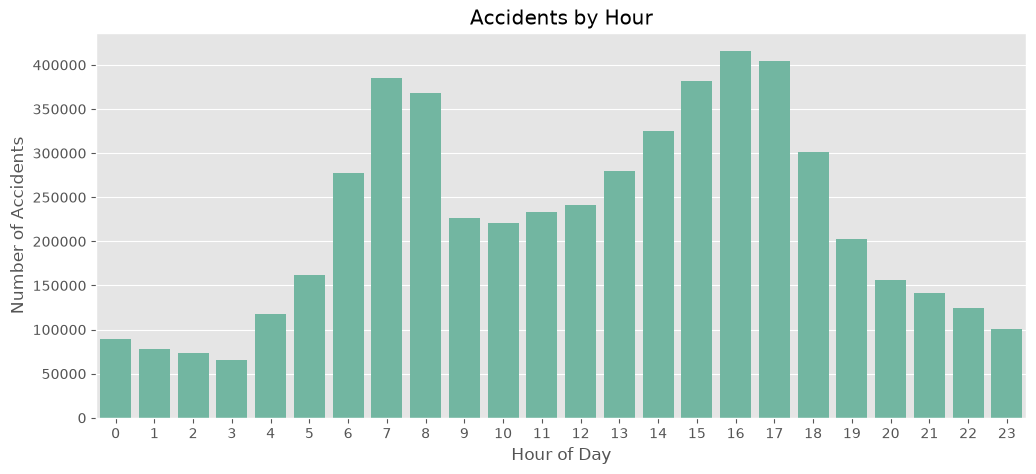

In [ ]:
# Accident by hours

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

sns.countplot(data=df, x="Hour")

plt.title("Accidents by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Accidents")
plt.show()

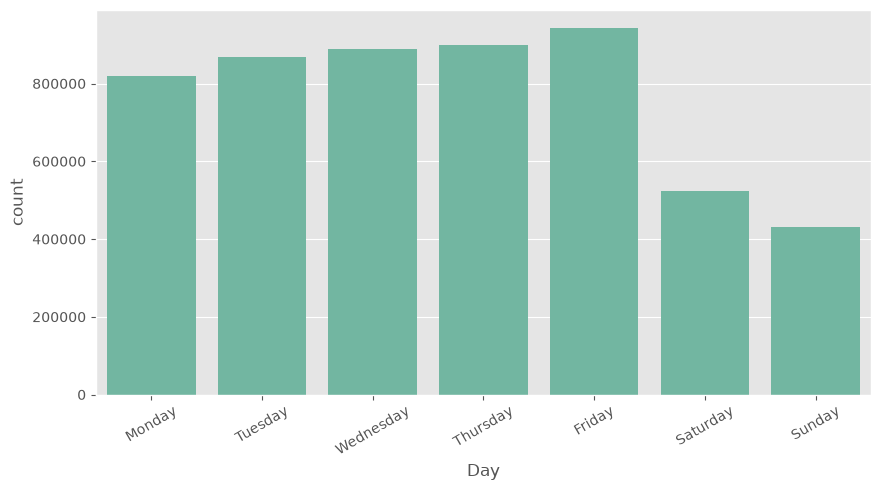

In [ ]:
# Accident by day

plt.figure(figsize=(10,5))

order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

sns.countplot(x="Day", data=df, order=order)

plt.xticks(rotation=30)

plt.show()

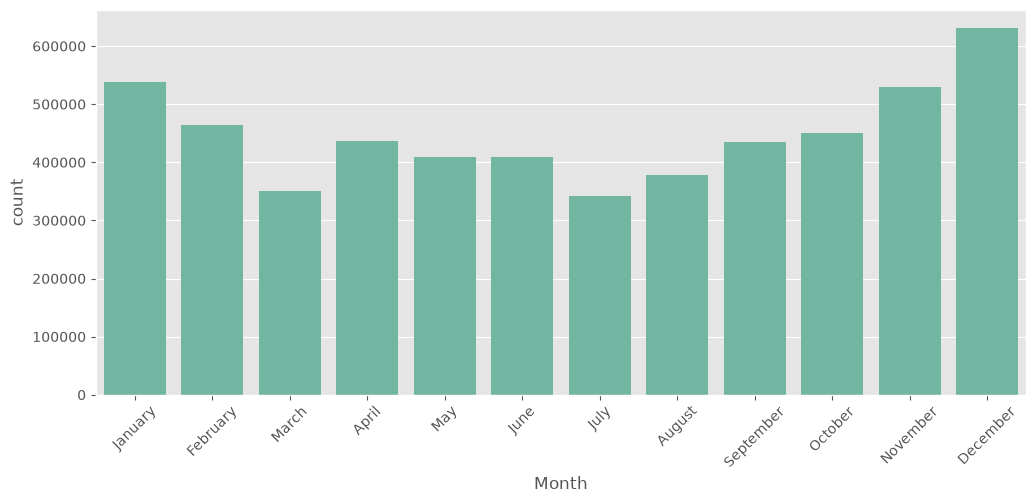

In [33]:
# Monthly accident

months = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

plt.figure(figsize=(12,5))

sns.countplot(
    x="Month",
    data=df,
    order=months
)

plt.xticks(rotation=45)

plt.show()

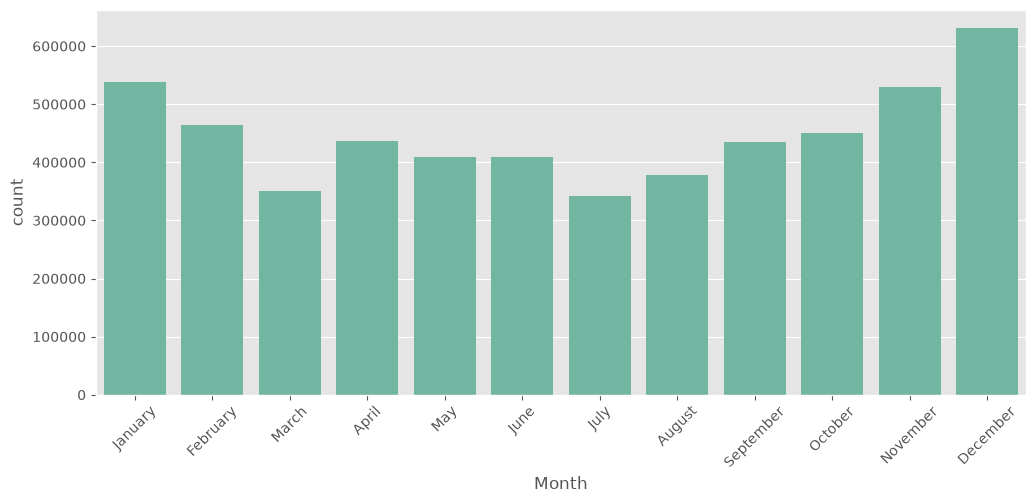

In [34]:
# Weather Condition 

months = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

plt.figure(figsize=(12,5))

sns.countplot(
    x="Month",
    data=df,
    order=months
)

plt.xticks(rotation=45)

plt.show()

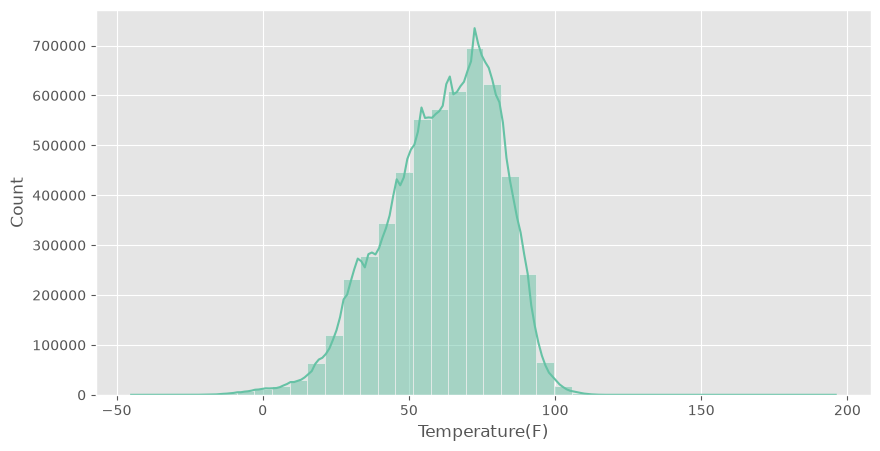

In [35]:
# Temperature Distribution

plt.figure(figsize=(10,5))

sns.histplot(
    df["Temperature(F)"],
    bins=40,
    kde=True
)

plt.show()

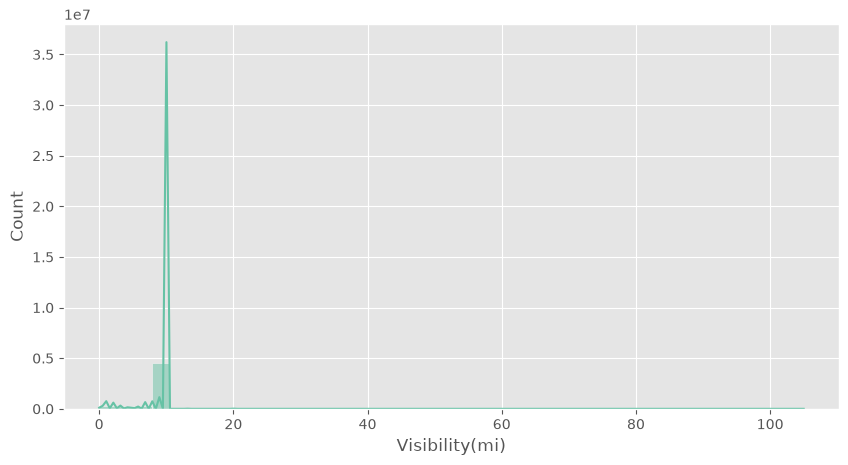

In [36]:
# Visibilty 

plt.figure(figsize=(10,5))

sns.histplot(
    df["Visibility(mi)"],
    bins=40,
    kde=True
)

plt.show()

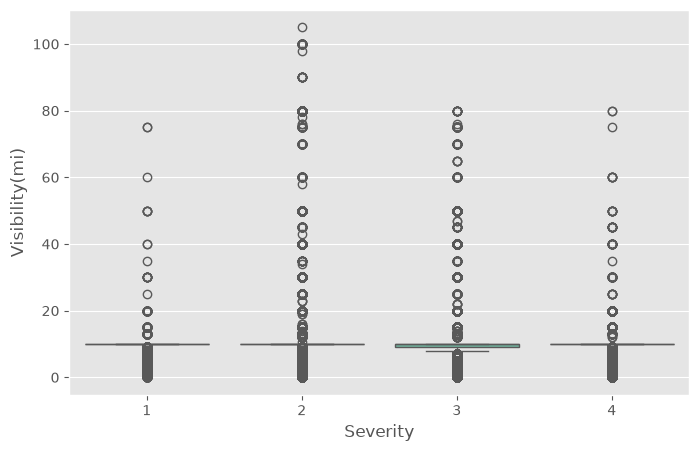

In [37]:
# Visibility vs Severity

plt.figure(figsize=(8,5))

sns.boxplot(
    x="Severity",
    y="Visibility(mi)",
    data=df
)

plt.show()

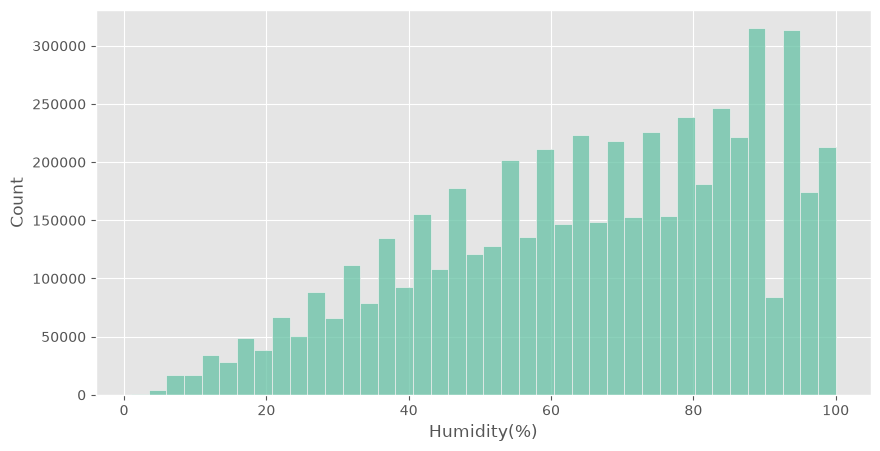

In [38]:
# humidity 

plt.figure(figsize=(10,5))

sns.histplot(df["Humidity(%)"], bins=40)

plt.show()

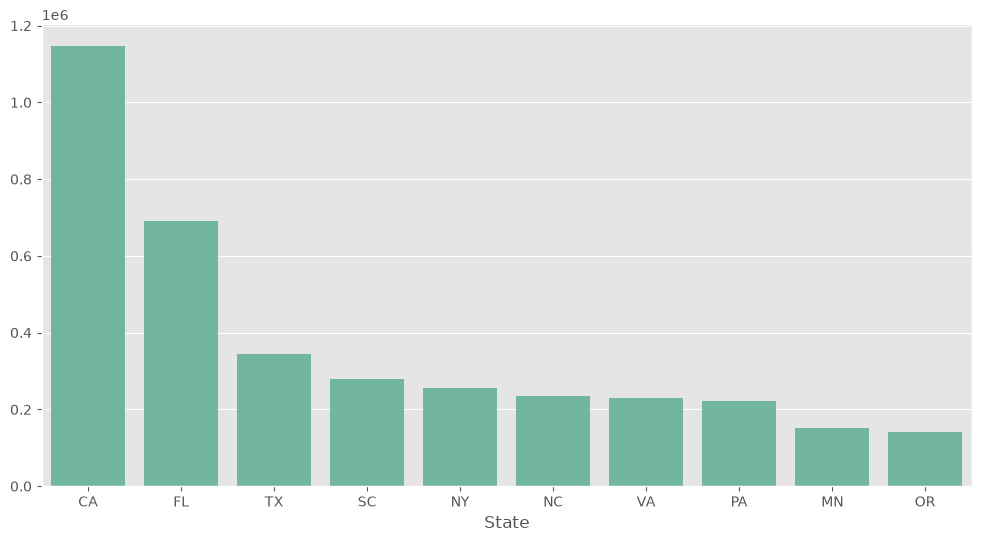

In [39]:
# Top States 

top_states = df["State"].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_states.index,
    y=top_states.values
)

plt.show()

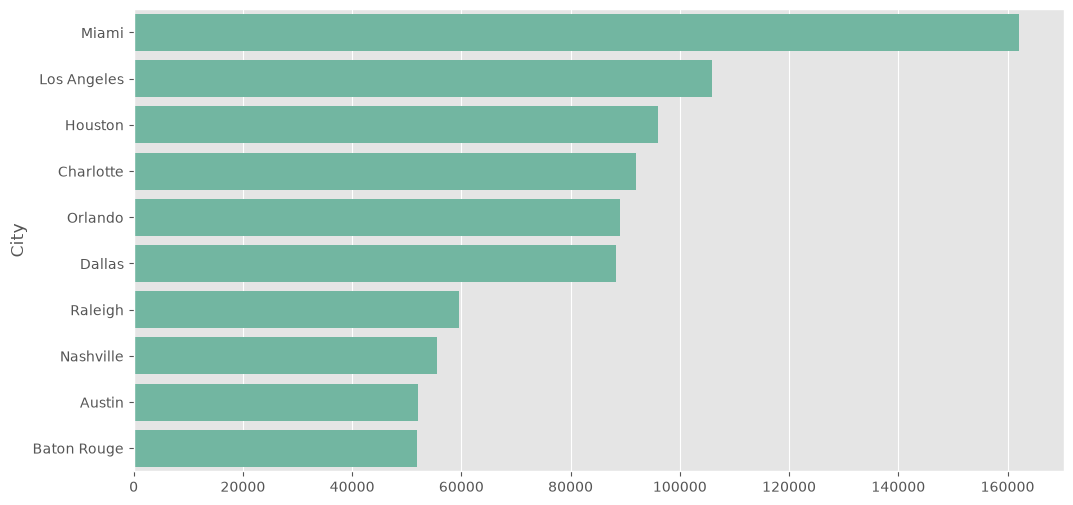

In [40]:
# Top cities

top_city = df["City"].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_city.values,
    y=top_city.index
)

plt.show()

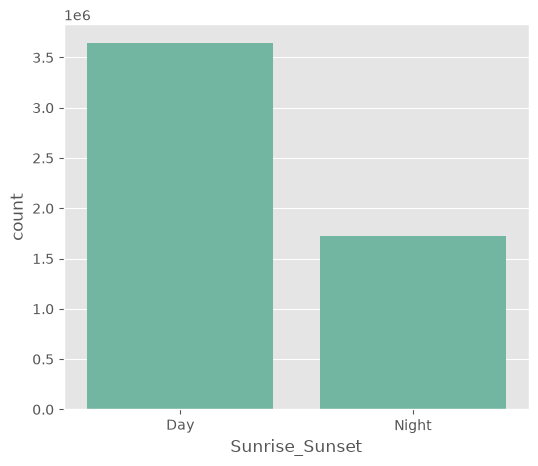

In [42]:
# Sunrise vs Sunset

plt.figure(figsize=(6,5))

sns.countplot(
    x="Sunrise_Sunset",
    data=df
)

plt.show()

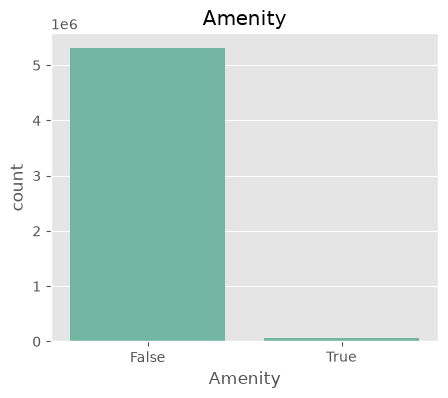

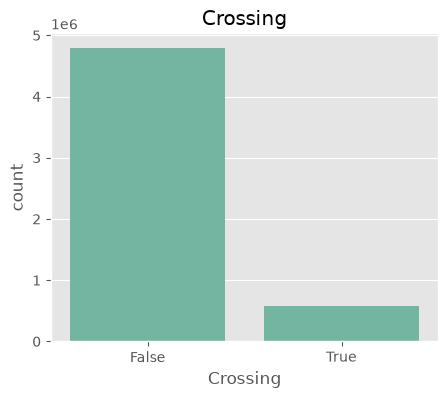

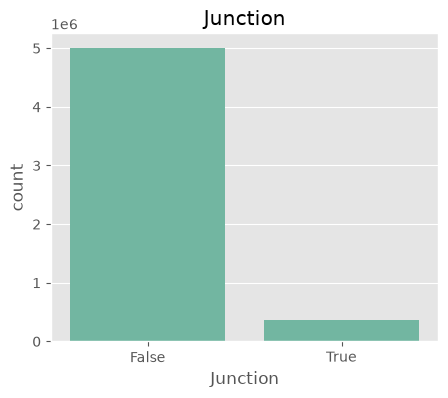

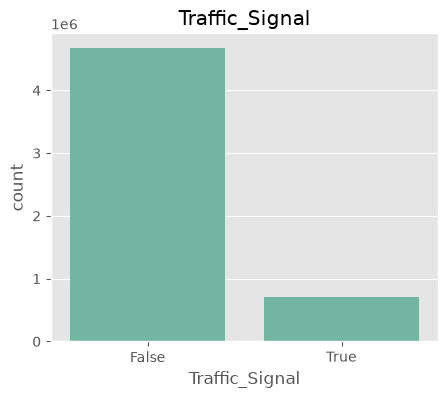

In [43]:
# Road Features

features = [
    "Amenity",
    "Crossing",
    "Junction",
    "Traffic_Signal"
]

for feature in features:

    plt.figure(figsize=(5,4))

    sns.countplot(
        x=feature,
        data=df
    )

    plt.title(feature)

    plt.show()

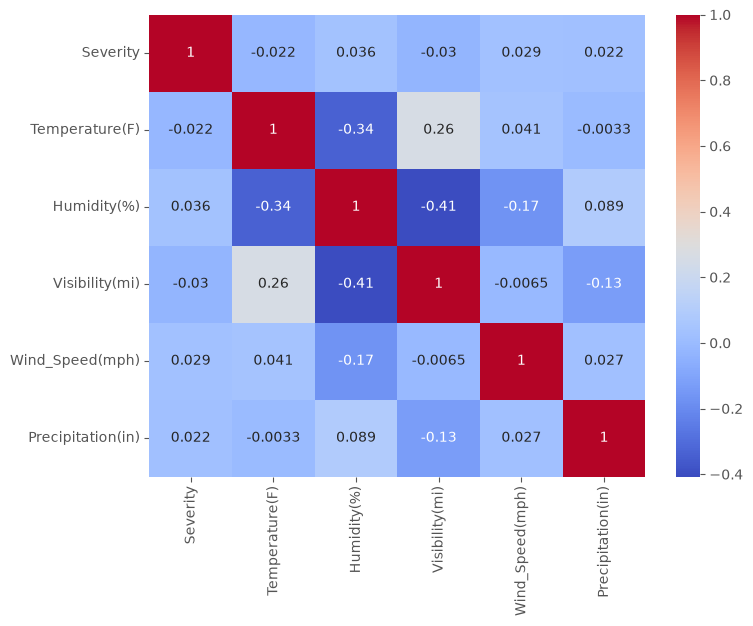

In [44]:
# Correlation Heatmap

plt.figure(figsize=(8,6))

corr = df[
[
    "Severity",
    "Temperature(F)",
    "Humidity(%)",
    "Visibility(mi)",
    "Wind_Speed(mph)",
    "Precipitation(in)"
]
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [45]:
# Accident Hotspot

sample = df.sample(5000, random_state=42)

In [46]:

fig = px.scatter_mapbox(
    sample,
    lat="Start_Lat",
    lon="Start_Lng",
    color="Severity",
    zoom=3,
    height=700,
    mapbox_style="carto-positron",
    title="Accident Hotspots in US"
)

fig.show()

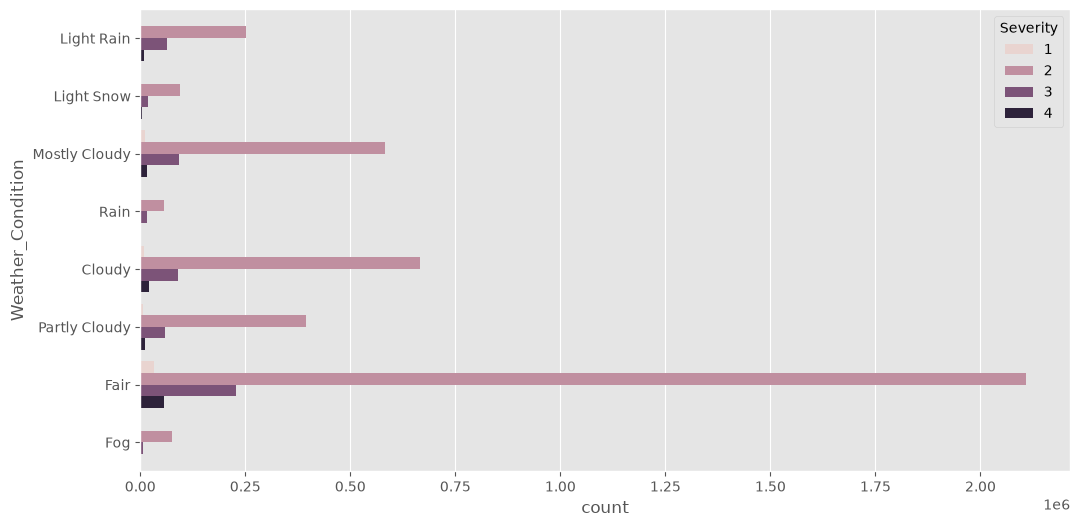

In [47]:
# Weather vs Severity 

top_weather = df["Weather_Condition"].value_counts().head(8).index

subset = df[df["Weather_Condition"].isin(top_weather)]

plt.figure(figsize=(12,6))

sns.countplot(
    y="Weather_Condition",
    hue="Severity",
    data=subset
)

plt.show()